In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pandas numpy torch

# **Imports and Configuration**

This cell imports all necessary libraries and sets up configurations such as the dataset path, model settings, and hyperparameters.

In [ ]:
# =========================
# Imports and Configuration
# =========================
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)


In [ ]:
# Configurations for dataset and model
CSV_PATH = "./Phishing_Email.csv"
MODEL_NAME = "distilbert-base-uncased"
OUTPUT_DIR = "./distilbert_phishing_model"

TEXT_COL = "Email Text"
LABEL_COL = "Email Type"

MAX_LENGTH = 256
TEST_SIZE = 0.15 # 15% of data to be used in testing
VAL_SIZE = 0.15  # 15% of data to validation
RANDOM_STATE = 42

BATCH_SIZE = 8
NUM_EPOCHS = 3
LR = 2e-5

The cell below connect to your google drive where there is your datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load Data**
This cell loads the dataset from a CSV file and displays the first few rows and the data types of each column to understand its structure.

In [ ]:
file_path = '/content/drive/My Drive/Datasets/Phishing_Email.csv'
df = pd.read_csv(file_path)
df.head()
# print(df.dtypes)

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


# **Handle Missing Data**

This step handles missing data by filling missing values in numeric columns with the mean and in categorical columns with the mode (most frequent value).

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Email Text,16
Email Type,0


In [ ]:
# =========================
# Step 2: Handle Missing Data
# =========================
# Check missing values and handle them using mean for numeric and mode for categorical
print("Missing values before cleaning:")
print(df.isnull().sum())

# For numeric columns, fill missing with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Ensure the output of fit_transform is 1D before assignment
df[numeric_cols] = df[numeric_cols].apply(lambda col: SimpleImputer(strategy='mean').fit_transform(col.values.reshape(-1, 1)).flatten())

# For categorical columns, fill missing with mode
categorical_cols = df.select_dtypes(include=['object']).columns
# Ensure the output of fit_transform is 1D before assignment
df[categorical_cols] = df[categorical_cols].apply(lambda col: SimpleImputer(strategy='most_frequent').fit_transform(col.values.reshape(-1, 1)).flatten())

# Verify missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

Missing values after cleaning:
Unnamed: 0    0
Email Text    0
Email Type    0
dtype: int64


# **removing duplicates**
This cell checks for and removes any duplicate rows in the dataset using .drop_duplicates().

In [ ]:
# =========================
# Remove Duplicates & Handle Missing Data
# =========================

# Display the original dataset shape and check for missing values before cleaning
print("Original dataset shape:", df.shape)
print("Missing values before cleaning:")
print(df.isnull().sum())

# For numeric columns, fill missing values with the mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].apply(lambda col: SimpleImputer(strategy='mean').fit_transform(col.values.reshape(-1, 1)).flatten())

# For categorical columns, fill missing values with the mode
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].apply(lambda col: SimpleImputer(strategy='most_frequent').fit_transform(col.values.reshape(-1, 1)).flatten())

# Remove any duplicate rows
df = df.drop_duplicates()

# Check the dataset shape and missing values after cleaning
print("\nCleaned dataset shape:", df.shape)
print("Missing values after cleaning:")
print(df.isnull().sum())

# Show the first few rows of the cleaned dataset
print("\nCleaned Dataset:")
print(df.head())

Original dataset shape: (18650, 3)
Missing values before cleaning:
Unnamed: 0    0
Email Text    0
Email Type    0
dtype: int64

Cleaned dataset shape: (18650, 3)
Missing values after cleaning:
Unnamed: 0    0
Email Text    0
Email Type    0
dtype: int64

Cleaned Dataset:
   Unnamed: 0                                         Email Text  \
0         0.0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1         1.0  the other side of * galicismos * * galicismo *...   
2         2.0  re : equistar deal tickets are you still avail...   
3         3.0  \nHello I am your hot lil horny toy.\n    I am...   
4         4.0  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  


# **Fix Inconsistent Data**
This cell standardizes text values to fix inconsistencies (e.g., "male" becomes "Male" and "AU" becomes "Australia").

In [ ]:
# =========================
# Step 4: Fix Inconsistent Data
# =========================
# Standardize inconsistent values in categorical columns
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()

# **Detect and Handle Outliers**
In this step, we detect outliers using the Z-score method, where data points with a Z-score above 3 are removed from the dataset.

In [ ]:
# =========================
# Step 5: Detect Outliers
# =========================
# Detect outliers using Z-score or IQR and remove/cap
from scipy import stats
z_scores = np.abs(stats.zscore(df[numeric_cols]))
df = df[(z_scores < 3).all(axis=1)]

# **Encode Categorical Data**
This cell encodes the target labels ("Safe Email" and "Phishing Email") into numerical values using label encoding.

In [ ]:
# =========================
# Display Encoded Labels
# =========================

# Ensure the 'label' column is created if it doesn't exist yet
# This line is moved here from cell 576z9tAuXld8 for immediate fix
df["label"] = df[LABEL_COL].map({"Safe Email": 0, "Phishing Email": 1})

# Check the first few rows to see the encoded labels
print("Encoded labels:")
print(df[['label']].head())

# Display the value counts of the encoded labels (to see the distribution of the labels)
print("\nLabel distribution:")
print(df['label'].value_counts())

Encoded labels:
   label
0      0
1      0
2      0
3      1
4      1

Label distribution:
label
0    11322
1     7328
Name: count, dtype: int64


First we will introduce one column called  special characters to see relation betwen specil characters and phishsing email

In [ ]:
# -------------------------------
# Special Characters Feature
# -------------------------------

# Create new column
df['special_chars'] = df['Email Text'].apply(
    lambda x: sum(not c.isalnum() and not c.isspace() for c in x)
)

# View sample
df[['Email Text', 'special_chars']].head()

,Email Text,special_chars
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",61
1,the other side of * galicismos * * galicismo *...,18
2,re : equistar deal tickets are you still avail...,96
3,Hello I am your hot lil horny toy.\n I am t...,112
4,software at incredibly low prices ( 86 % lower...,27


In [ ]:
df.sort_values(by='special_chars', ascending=False).head()

,Unnamed: 0,Email Text,Email Type,label,special_chars
12500,12501.0,"0,""Subject: great part-time or summer job ! * ...",Safe Email,0,1202645
11294,11295.0,change your settings: http://blo.gs/settings.p...,Safe Email,0,23316
8983,8984.0,ãŠä¸–è©±ã«ãªã£ã¦ãŠã‚Šã¾ã™ã€‚ä¸‰è±åŒ–å...,Safe Email,0,7885
16202,16203.0,::: L I N K S F O R T H E D A Y :::Today...,Safe Email,0,7150
14542,14543.0,"fw : "" red , white and blue out "" - - - - - or...",Safe Email,0,5294


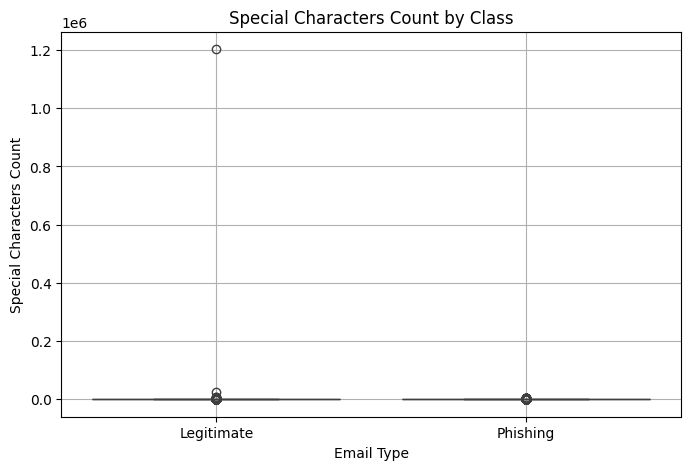

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Email Type')
plt.ylabel('Special Characters Count')

plt.grid(True)
plt.show()

# **Scale Data**  
This step applies Min-Max scaling to the numeric columns in the dataset, normalizing the values between 0 and 1.

In [ ]:
# =========================
# Scale Numeric Columns
# =========================

# Apply Min-Max scaling to numeric columns
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Display the first few rows of the dataset after scaling
# print("\nDataset after scaling numeric columns:")
df.head()

,Unnamed: 0,Email Text,Email Type,label,special_chars
0,0.000000,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0,61
1,0.000054,the other side of * galicismos * * galicismo *...,Safe Email,0,18
2,0.000107,re : equistar deal tickets are you still avail...,Safe Email,0,96
3,0.000161,Hello I am your hot lil horny toy.\n I am t...,Phishing Email,1,112
4,0.000214,software at incredibly low prices ( 86 % lower...,Phishing Email,1,27


# **Feature Engineering**
A new feature text_length is created, which stores the length of the email text. This can be useful for modeling purposes, as it may correlate with whether an email is phishing or not.

In [ ]:
# =========================
# Step 8: Feature Engineering
# =========================
# Add a new feature 'text_length' based on the length of the email text
df['text_length'] = df[TEXT_COL].apply(len)

In [ ]:
# =========================
# Final Cleaned and Preprocessed Dataset
# =========================

# Display the first few rows of the final cleaned and preprocessed dataset
print("\nFinal cleaned and preprocessed dataset:")
print(df.head())

# Optionally, save the final dataset to a CSV file for reference
df.to_csv("final_cleaned_preprocessed_dataset.csv", index=False)


Final cleaned and preprocessed dataset:
   Unnamed: 0                                         Email Text  \
0    0.000000  re : 6 . 1100 , disc : uniformitarianism , re ...   
1    0.000054  the other side of * galicismos * * galicismo *...   
2    0.000107  re : equistar deal tickets are you still avail...   
3    0.000161  Hello I am your hot lil horny toy.\n    I am t...   
4    0.000214  software at incredibly low prices ( 86 % lower...   

       Email Type  label  special_chars  text_length  
0      Safe Email      0             61         1030  
1      Safe Email      0             18          479  
2      Safe Email      0             96         1245  
3  Phishing Email      1            112          687  
4  Phishing Email      1             27          441  


# **Train / Validation / Test Split**
This cell splits the dataset into training, validation, and test sets with stratified sampling, ensuring that each set has a balanced distribution of the target classes.

In [ ]:
# =========================
# Step 9: Split Dataset
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=(TEST_SIZE + VAL_SIZE),
    stratify=df["label"],
    random_state=RANDOM_STATE
)

relative_val_size = VAL_SIZE / (TEST_SIZE + VAL_SIZE)

val_df, test_df = train_test_split(
    temp_df,
    test_size=(1 - relative_val_size),
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

# Show the split sizes
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (13055, 6)
Val: (2797, 6)
Test: (2798, 6)


# **Hugging Face Datasets**
This cell converts the pandas DataFrame into Hugging Face datasets for training, validation, and testing, which will be used by the model.

In [ ]:
# =========================
# HUGGING FACE DATASETS
# =========================
train_ds = Dataset.from_pandas(train_df[[TEXT_COL, "label"]], preserve_index=False)
val_ds = Dataset.from_pandas(val_df[[TEXT_COL, "label"]], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[[TEXT_COL, "label"]], preserve_index=False)

# **Tokenization**
This cell tokenizes the email text, converting it into a format that can be input into the model. It uses the pre-trained tokenizer from Hugging Face.

In [ ]:
# =========================
# TOKENIZER
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/13055 [00:00<?, ? examples/s]

Map:   0%|          | 0/2797 [00:00<?, ? examples/s]

Map:   0%|          | 0/2798 [00:00<?, ? examples/s]

# **Model Setup**
This cell loads the pre-trained DistilBERT model for sequence classification with two output labels (Safe Email, Phishing Email).

In [ ]:
# =========================
# MODEL
# =========================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **Metrics Function**
This function computes various classification metrics (accuracy, precision, recall, and F1 score) to evaluate model performance.

In [ ]:
# =========================
# METRICS
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# **Training Arguments**
This cell sets up the training arguments, including batch size, number of epochs, learning rate, and other training parameters.

In [ ]:
# =========================
# TRAINING ARGS
# =========================
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    logging_steps=20,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none"
)

**bold text**# **Trainer Setup**
This cell creates a Trainer object, which is responsible for training and evaluating the model.

In [ ]:
# =========================
# TRAINER
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# **Training the Model**

In [ ]:
# =========================
# TRAIN
# =========================
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.137025,0.083988,0.974973,0.950131,0.988171,0.968778
2,0.048167,0.093240,0.977118,0.960819,0.981802,0.971197
3,0.028807,0.093623,0.976403,0.958296,0.982712,0.970350


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4896, training_loss=0.07133295645121655, metrics={'train_runtime': 392.2675, 'train_samples_per_second': 99.843, 'train_steps_per_second': 12.481, 'total_flos': 2590770475473696.0, 'train_loss': 0.07133295645121655, 'epoch': 3.0})

# **Final Test Evaluation**
This cell evaluates the model on the test set and outputs the metrics and confusion matrix. It also saves the trained model and tokenizer for future use.


Test metrics: {'test_loss': 0.09598615765571594, 'test_accuracy': 0.9753395282344531, 'test_precision': 0.9557522123893806, 'test_recall': 0.9827115559599636, 'test_f1': 0.9690444145356663, 'test_runtime': 9.6764, 'test_samples_per_second': 289.158, 'test_steps_per_second': 36.171}


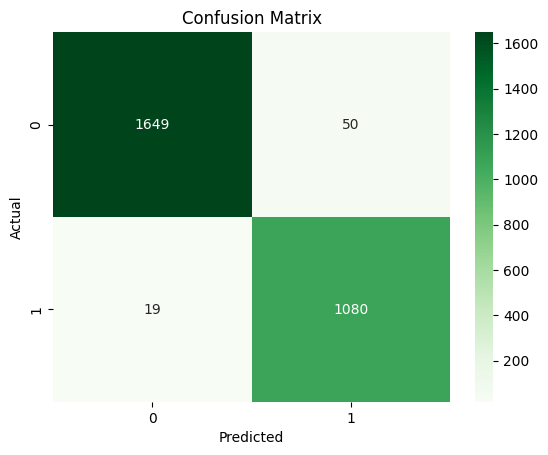


Confusion Matrix:
[[1649   50]
 [  19 1080]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: ./distilbert_phishing_model


In [ ]:
# =========================
# FINAL TEST EVALUATION
# =========================
pred_output = trainer.predict(test_ds)

test_metrics = pred_output.metrics
print("\nTest metrics:", test_metrics)

preds = np.argmax(pred_output.predictions, axis=-1)
labels = pred_output.label_ids
cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nConfusion Matrix:")
print(cm)

# save model + tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nModel saved to: {OUTPUT_DIR}")